# Horror Games on Steam: Tag Analysis

This notebook analyzes my scaled Steam horror games dataset. Each row in the dataset represents one Steam store page for a horror game. The dataset includes the game title, Steam URL, Steam tags, and a short description.

The goal of this notebook is to explore how horror games are represented on Steam through tags. I focus on tags because they show how Steam organizes games and how horror overlaps with other genres, styles, mechanics, and player experiences.

## Import Libraries

I only use pandas in this notebook. Pandas helps me load the CSV file, clean the data, count tags, and organize the results into tables.

In [2]:
import pandas as pd

## Load the Dataset

This cell loads my final scaled horror games dataset. The file is a CSV created from my Steam web scraping script.

In [4]:
df = pd.read_csv("scaled_horror_games.csv")

df.head()

,title,steam_url,tags,description
0,Unknown,https://store.steampowered.com/app/381210/Dead...,"Gore, Blood, Violent, Mature",No description
1,Unknown,https://store.steampowered.com/app/3764200/Res...,NaN,No description
2,Unknown,https://store.steampowered.com/app/1151340/Fal...,NaN,No description
3,Ready or Not,https://store.steampowered.com/app/1144200/Rea...,"Tactical, Realistic, FPS, Shooter, Multiplayer...","Ready or Not is an intense, tactical, first-pe..."
4,Once Human,https://store.steampowered.com/app/2139460/Onc...,"Free to Play, Survival, Multiplayer, Open Worl...",Once Human is a multiplayer open-world surviva...


The dataset contains 600 rows and 4 columns. Each row represents one Steam horror game page, and the columns include the game title, Steam URL, tags, and description.

In [5]:
df.shape 

(600, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        600 non-null    object
 1   steam_url    600 non-null    object
 2   tags         514 non-null    object
 3   description  600 non-null    object
dtypes: object(4)
memory usage: 18.9+ KB


## Check for Missing Data

Before analyzing the dataset, I check for missing values. This is important because web scraping does not always collect every field perfectly. Some Steam pages may be missing tags or descriptions.

In [7]:
df.isna().sum()

title           0
steam_url       0
tags           86
description     0
dtype: int64

## Clean Missing Values

I replace missing tags and descriptions with empty text. This makes the later code easier to run because it avoids errors when splitting or counting tags.

In [8]:
df["tags"] = df["tags"].fillna("")
df["description"] = df["description"].fillna("")

## Split the Tags

The tags column stores multiple tags in one cell, separated by commas. To analyze them, I split the tags so each individual tag gets its own row.

This makes it possible to count how often each tag appears across the dataset.

In [9]:
tag_rows = []

for index, row in df.iterrows():
    tags = row["tags"].split(",")
    
    for tag in tags:
        tag = tag.strip()
        
        if tag != "":
            tag_rows.append({
                "title": row["title"],
                "tag": tag
            })

tags_df = pd.DataFrame(tag_rows)

tags_df.head()

,title,tag
0,Unknown,Gore
1,Unknown,Blood
2,Unknown,Violent
3,Unknown,Mature
4,Ready or Not,Tactical


## Count the Most Common Tags

This cell counts how often each Steam tag appears in the dataset. This helps show which labels are most commonly connected to horror games on Steam.

In [10]:
top_tags = tags_df["tag"].value_counts()

top_tags.head(15)

tag
Horror                  457
Singleplayer            314
Atmospheric             294
Adventure               287
Action                  270
First-Person            265
Psychological Horror    230
Dark                    198
Story Rich              187
Survival Horror         178
Exploration             170
Indie                   169
Multiplayer             168
Gore                    159
3D                      145
Name: count, dtype: int64

## Top 15 Steam Tags

This chart shows the 15 most common tags in the dataset. The purpose is to see what categories appear most often alongside horror.

This helps answer my main question because it shows that horror games are not only labeled as “Horror.” They also overlap with tags related to mood, gameplay style, perspective, story, action, and survival.

<Axes: title={'center': 'Top 15 Steam Tags in the Horror Games Dataset'}, ylabel='tag'>

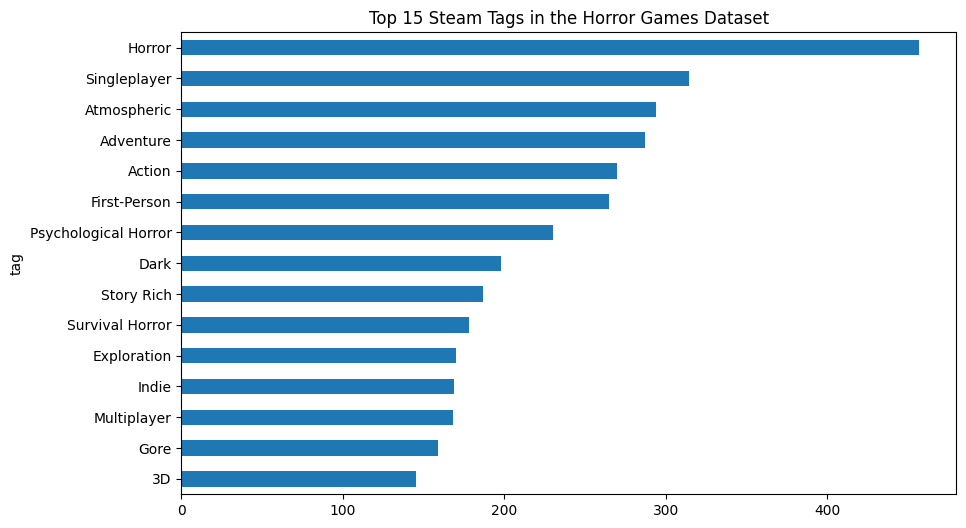

In [13]:
top_tags.head(15).sort_values().plot(
    kind="barh",
    title="Top 15 Steam Tags in the Horror Games Dataset",
    figsize=(10, 6)
)

The most common tag is Horror, which makes sense because this dataset was collected from Steam horror game pages. The other common tags show that horror games overlap with many other categories, such as Singleplayer, Atmospheric, Adventure, Action, First-Person, Psychological Horror, Dark, Story Rich, and Survival Horror.

This supports my main idea that horror on Steam is not one simple genre. It is a flexible category that connects to mood, mechanics, story, and gameplay style.

## Horror-Related Styles and Themes

For this section, I selected tags that are especially connected to horror style, mood, or theme. This helps me look more closely at what kind of horror appears most often in the dataset.

In [14]:
horror_style_tags = [
    "Atmospheric",
    "Psychological Horror",
    "Dark",
    "Story Rich",
    "Survival Horror",
    "Gore",
    "Mystery",
    "Survival",
    "Violent",
    "Thriller"
]

horror_styles = top_tags[top_tags.index.isin(horror_style_tags)]

horror_styles

tag
Atmospheric             294
Psychological Horror    230
Dark                    198
Story Rich              187
Survival Horror         178
Gore                    159
Mystery                 123
Survival                112
Violent                 100
Thriller                 63
Name: count, dtype: int64

## Most Common Horror Styles

This chart compares horror-related tags such as Atmospheric, Psychological Horror, Survival Horror, Gore, and Mystery. These tags help show how horror games are marketed on Steam.

<Axes: title={'center': 'Most Common Horror-Related Styles and Themes'}, ylabel='tag'>

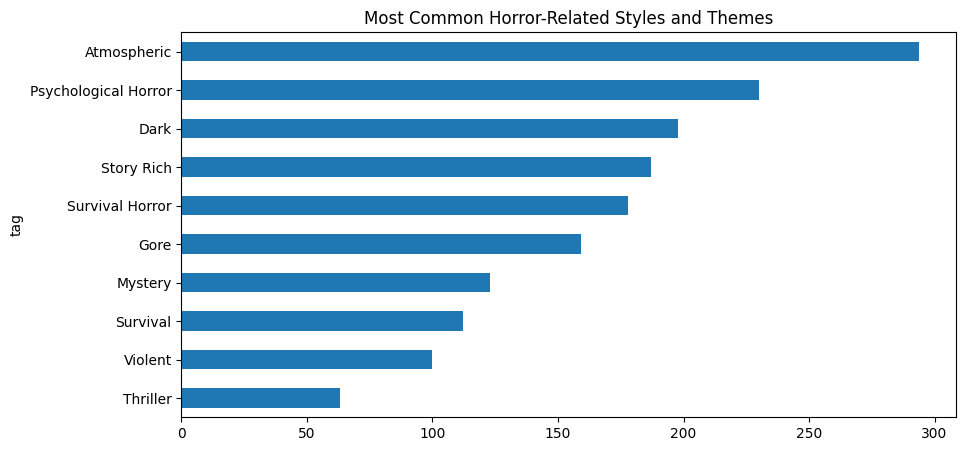

In [15]:
horror_styles.sort_values().plot(
    kind="barh",
    title="Most Common Horror-Related Styles and Themes",
    figsize=(10, 5)
)

This chart helps show what kinds of horror are most common in the dataset. Tags like Atmospheric, Psychological Horror, Dark, Story Rich, and Survival Horror suggest that many horror games on Steam are marketed through mood, tension, story, and survival.

This is useful because it shows that horror is not only about gore or monsters. A lot of horror games are described through atmosphere and emotional experience.

## Single-Player, Multiplayer, and Co-op Horror

This section compares tags related to how players experience horror games. I wanted to see whether horror games on Steam are mostly presented as single-player experiences or if multiplayer and co-op horror also appear often.

In [16]:
play_style_tags = [
    "Singleplayer",
    "Multiplayer",
    "Co-op",
    "Online Co-Op"
]

play_styles = top_tags[top_tags.index.isin(play_style_tags)]

play_styles

tag
Singleplayer    314
Multiplayer     168
Co-op           120
Online Co-Op    101
Name: count, dtype: int64

## Play Style Comparison

This chart compares Singleplayer, Multiplayer, Co-op, and Online Co-Op tags. This helps show whether horror games on Steam are mostly presented as individual experiences or shared/social experiences.

<Axes: title={'center': 'Single-Player vs Multiplayer and Co-op Horror'}, ylabel='tag'>

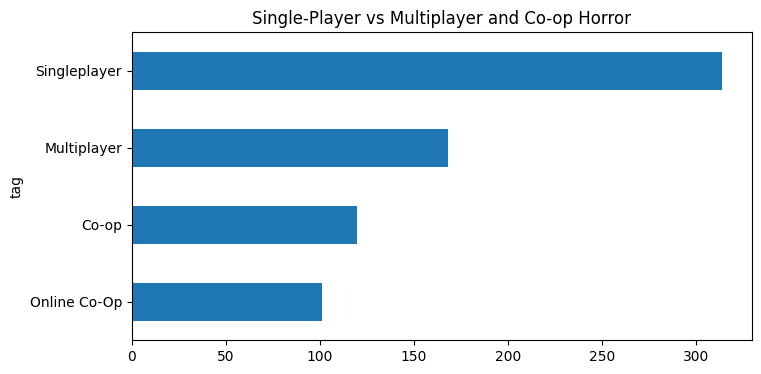

In [17]:
play_styles.sort_values().plot(
    kind="barh",
    title="Single-Player vs Multiplayer and Co-op Horror",
    figsize=(8, 4)
)

Singleplayer appears more often than Multiplayer, Co-op, and Online Co-Op. This suggests that many Steam horror games are still presented as individual experiences. However, multiplayer and co-op horror also appear often, which shows that horror can also be a shared social experience.

## Broader Horror Categories

For this section, I grouped related Steam tags into broader categories based on my own interpretation. These categories are not perfect, but they help summarize the main ways horror games are represented on Steam.

One game can count in more than one category because Steam games usually have multiple tags. This is important because it shows that horror games often overlap across different styles and mechanics.

In [18]:
category_map = {
    "Mood / Atmosphere": ["Atmospheric", "Dark", "Mystery"],
    "Psychological / Story": ["Psychological Horror", "Story Rich"],
    "Survival": ["Survival Horror", "Survival"],
    "Action / Combat": ["Action", "Shooter", "FPS", "Gore", "Violent"],
    "Social / Multiplayer": ["Multiplayer", "Co-op", "Online Co-Op"]
}

In [19]:
category_counts = {}

for category, selected_tags in category_map.items():
    count = tags_df[tags_df["tag"].isin(selected_tags)]["title"].nunique()
    category_counts[category] = count

category_counts = pd.Series(category_counts)

category_counts

Mood / Atmosphere        359
Psychological / Story    300
Survival                 211
Action / Combat          316
Social / Multiplayer     186
dtype: int64

## Broad Category Chart

This chart shows how many games fall into each broader category based on their tags.

<Axes: title={'center': 'Broad Categories in Steam Horror Games'}>

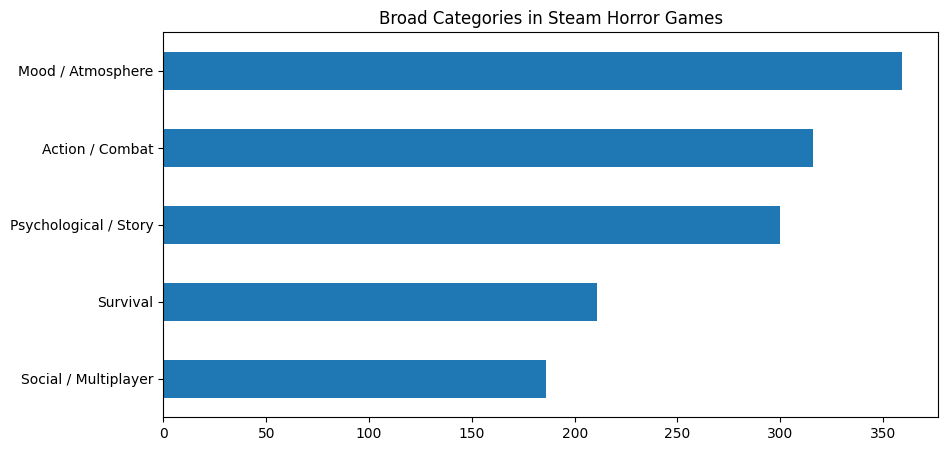

In [20]:
category_counts.sort_values().plot(
    kind="barh",
    title="Broad Categories in Steam Horror Games",
    figsize=(10, 5)
)

This chart shows that horror games are represented through different kinds of categories. Mood and atmosphere are very common, but action, survival, story, and multiplayer tags also appear.

One game can count in more than one category because Steam games usually have multiple tags. This actually supports the point that horror on Steam is a hybrid category instead of one single genre.

## Final Takeaway

These tag visualizations show that horror games on Steam are not represented as one simple category. Horror overlaps with atmosphere, action, survival, story, psychological horror, multiplayer, and co-op gameplay.

The most important takeaway is that Steam makes horror searchable through tags. These tags are useful because they show patterns across hundreds of games, but they also simplify the experience of horror. A tag can show how a game is represented on Steam, but it cannot fully capture what it feels like to actually play the game.